In [1]:
import sys
sys.path.append("..")

import torch

from source.system import SystemParams
from source.policy import NeuralPolicy
from source.utils import read_csv

from source.training import train_net

import matplotlib.pyplot as plt

plt.style.use("../styles/paper.mplstyle")

from source.diagnostics import check_energy_balance

from source.stochastic_processes import make_price_function
from source.simulation import rollout_trajectory
from source.plotting import (
    plot_state_trajectories,
    plot_control_trajectories,
    plot_endogenous_trajectories,
    plot_cost_trajectories,
)

In [2]:
EPOCHS = 20
BATCH_SIZE = 32

DEVICE = torch.device("cpu")

params = SystemParams()

S0_single = torch.tensor([[0., 0., 100., 0.01]], device=DEVICE)

energy_prices = read_csv("../data/eprice_test.csv")

price_history = energy_prices[:24]
future_price = energy_prices[24:]

policy = NeuralPolicy().to(DEVICE)

optimizer = torch.optim.AdamW(
    policy.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

res = train_net(
    policy=policy,
    optimizer=optimizer,
    device=DEVICE,
    params=params,
    S0_single=S0_single,
    endog_history=price_history,
    future_endog=future_price,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=True
)

[001] J_train=8.8662 | J_eval(det)=8.3548
[002] J_train=8.5037 | J_eval(det)=8.0887
[003] J_train=8.1583 | J_eval(det)=7.8140
[004] J_train=7.8656 | J_eval(det)=7.5068
[005] J_train=7.4629 | J_eval(det)=7.0395
[006] J_train=7.1000 | J_eval(det)=6.3841
[007] J_train=6.3347 | J_eval(det)=5.6477
[008] J_train=5.8139 | J_eval(det)=4.9467
[009] J_train=5.0170 | J_eval(det)=4.1285
[010] J_train=4.3804 | J_eval(det)=3.2275
[011] J_train=3.7929 | J_eval(det)=2.4553
[012] J_train=2.3768 | J_eval(det)=1.5986
[013] J_train=1.8222 | J_eval(det)=0.5849
[014] J_train=0.6110 | J_eval(det)=-0.4312
[015] J_train=-0.4469 | J_eval(det)=-2.0247
[016] J_train=-1.7739 | J_eval(det)=-4.6596
[017] J_train=-4.2721 | J_eval(det)=-5.3501
[018] J_train=-5.1355 | J_eval(det)=-5.4867
[019] J_train=-5.3211 | J_eval(det)=-5.6245
[020] J_train=-5.5641 | J_eval(det)=-5.6375

Training ready in 14.5s. Epoch: 20. Best J=-5.5641


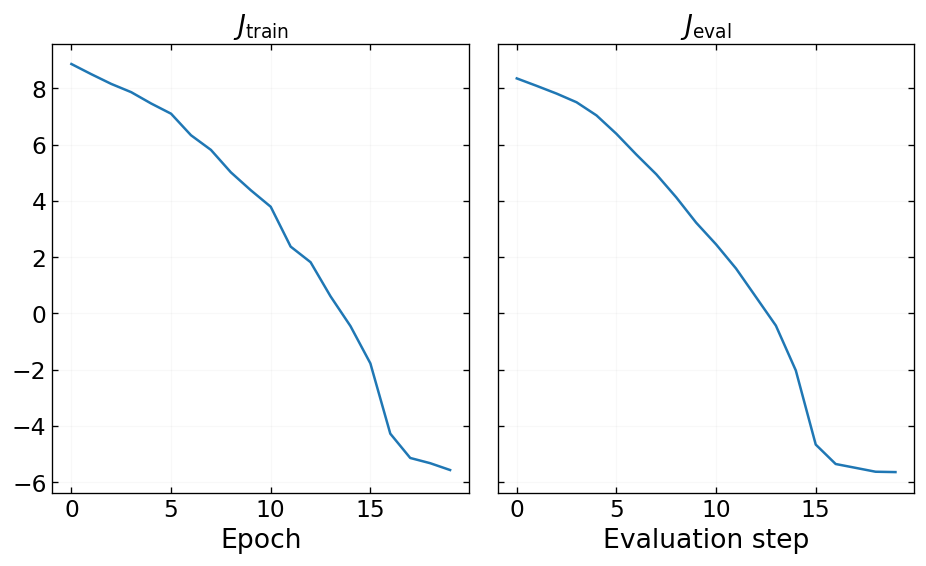

In [7]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True)

ax[0].plot(res["J_train_hist"])
ax[0].set_title(r"$J_{\mathrm{train}}$")
ax[0].set_xlabel("Epoch")

ax[1].plot(res["J_eval_hist"])
ax[1].set_title(r"$J_{\mathrm{eval}}$")
ax[1].set_xlabel("Evaluation step")

plt.tight_layout()
plt.show()

In [8]:
next_price_fn = make_price_function(price_history, future_price, params)

S0_demo = S0_single.repeat(20, 1)

t_hist, S_hist, endog_hist, u_hist, A_hist, B_hist, c_hist, J_episode = rollout_trajectory(
    policy=policy,
    S0=S0_demo,
    T=24.0,
    params=params,
    next_price_fn=next_price_fn,
    stochastic=True,
    seed=1,
    device=DEVICE,
)

print(f"Demo rollout J: {J_episode:.4f}")

Demo rollout J: -5.5050


In [9]:
check_energy_balance(endog_hist, dt=params.dt)

{'max_abs_error': 1.862645149230957e-09,
 'mean_abs_error': 3.801316466461868e-12,
 'mean_Ub': 16.682249069213867,
 'max_Ub': 118.38768768310547}

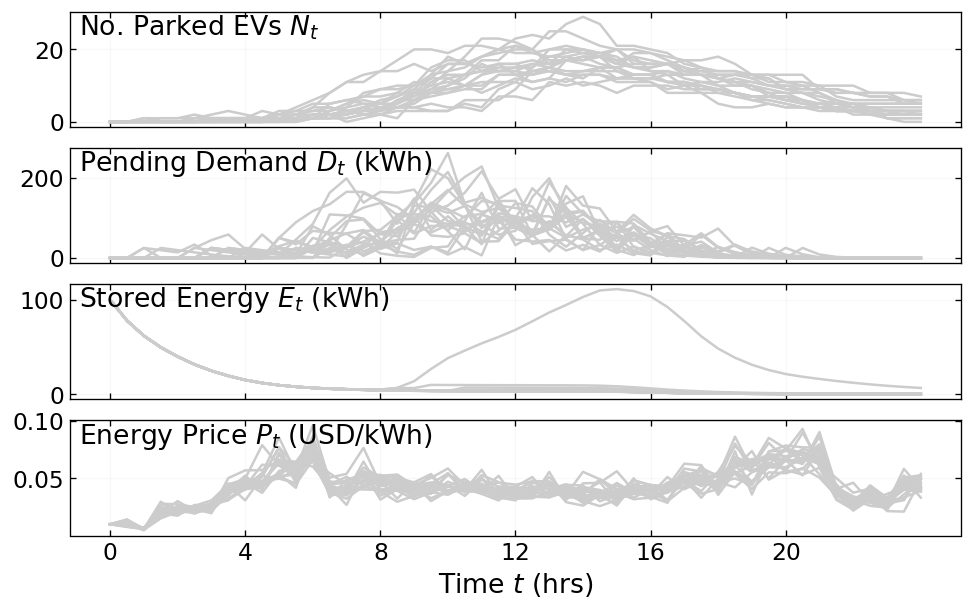

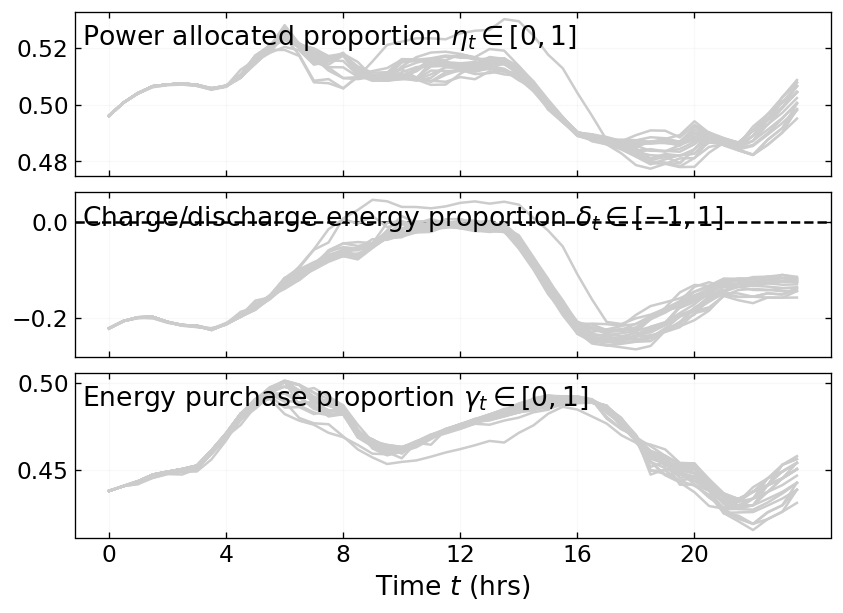

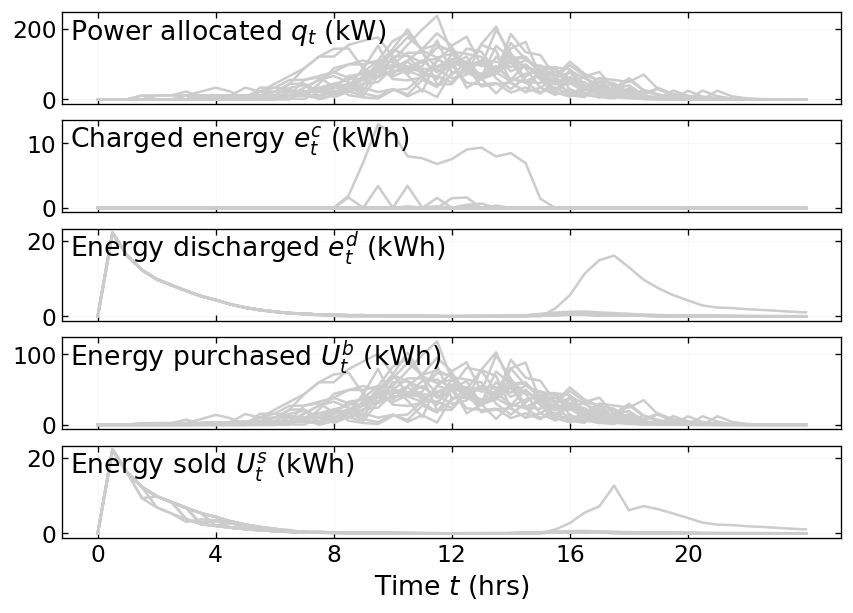

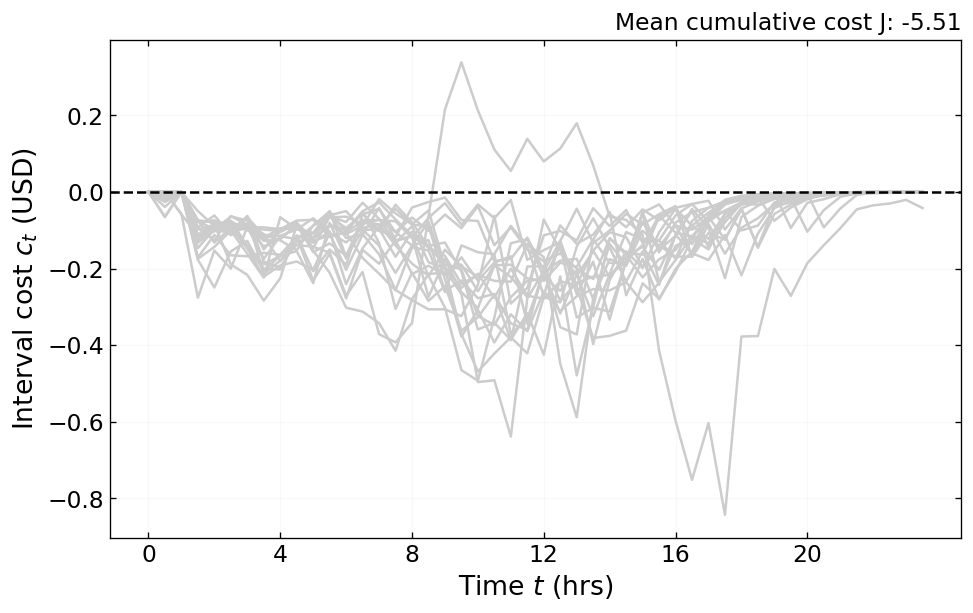

In [10]:
plot_state_trajectories(t_hist, S_hist)
plot_control_trajectories(t_hist, u_hist)
plot_endogenous_trajectories(t_hist, endog_hist)
plot_cost_trajectories(t_hist, c_hist, J_episode)